**Predicting Broadcom (AVGO) price with help of Monte Carlo Forecasting**

In [1]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
from scipy.stats import norm
%matplotlib inline
import yfinance as yf

In [2]:
ticker = 'AVGO'
data = pd.DataFrame()
data[ticker] = yf.Ticker(ticker).history(start="2016-01-01")['Close']

In [3]:
data.tail(5)

,AVGO
Date,
2026-04-01 00:00:00-04:00,313.489990
2026-04-02 00:00:00-04:00,314.549988
2026-04-06 00:00:00-04:00,314.429993
2026-04-07 00:00:00-04:00,333.970001
2026-04-08 00:00:00-04:00,351.345001


In [4]:
log_returns = np.log(1+data.pct_change())
log_returns.head(5)

,AVGO
Date,
2016-01-04 00:00:00-05:00,NaN
2016-01-05 00:00:00-05:00,-0.034027
2016-01-06 00:00:00-05:00,-0.031242
2016-01-07 00:00:00-05:00,-0.032327
2016-01-08 00:00:00-05:00,-0.006608


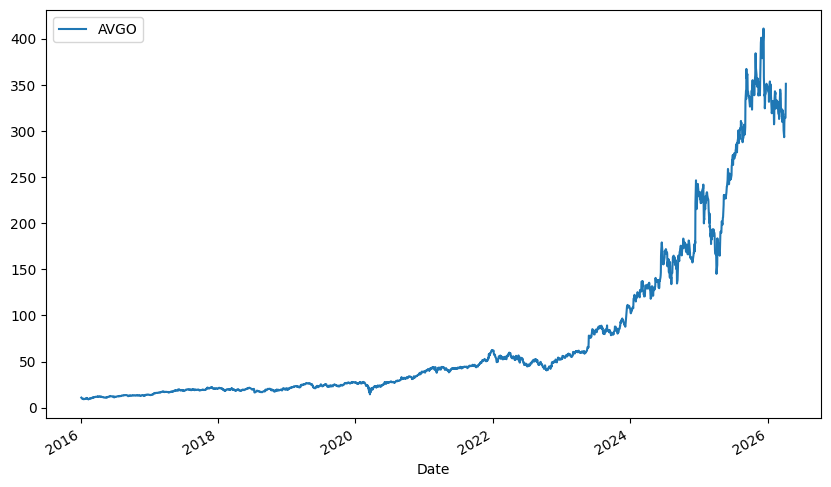

In [5]:
data.plot(figsize=(10, 6));

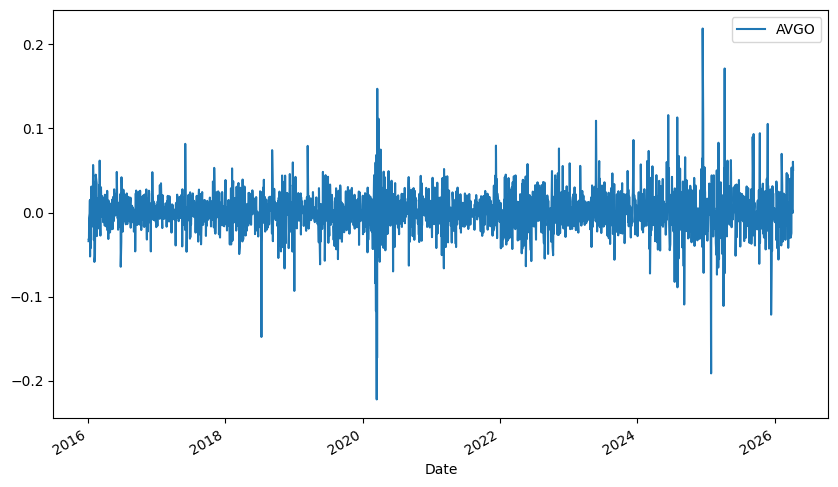

In [7]:
log_returns.plot(figsize=(10, 6));

In [8]:
u = log_returns.mean()
u

AVGO    0.001348
dtype: float64

In [9]:
var = log_returns.var()
var

AVGO    0.000602
dtype: float64

*Drift = mean - (1/2) var*

In [11]:
drift = u - (0.5 * var)
drift

AVGO    0.001047
dtype: float64

In [12]:
stdev = log_returns.std()
stdev

AVGO    0.024528
dtype: float64

**Brownian motion:**
*r = drift + stdev * e^r*

In [14]:
drift.values

array([0.00104748])

.values will return array as an output 

*Calculating the value (z-score) corresponding to a given probability using norm.ppf()*

In [23]:
x = np.random.rand(10,2)
x

array([[0.42729336, 0.41999641],
       [0.22945228, 0.68631465],
       [0.15624189, 0.40801801],
       [0.55214223, 0.47022056],
       [0.23573166, 0.65697901],
       [0.62966046, 0.01831134],
       [0.10527233, 0.04215339],
       [0.06320557, 0.83742581],
       [0.35407449, 0.20105848],
       [0.03817265, 0.09633564]])

In [24]:
Z = norm.ppf(x)
Z

array([[-0.1832693 , -0.20190267],
       [-0.74065186,  0.48543093],
       [-1.01002403, -0.23264638],
       [ 0.13107556, -0.07471545],
       [-0.72010018,  0.40423218],
       [ 0.33095421, -2.08994576],
       [-1.25206919, -1.72622589],
       [-1.52840854,  0.98393316],
       [-0.37434321, -0.83784643],
       [-1.77229679, -1.30271734]])

*t_intervals is no.of days and iterations is number of sample or result*

In [25]:
t_intervals = 1000
iterations = 10

**daily return = e^r**

*r = drift +stdev * z*

In [26]:
daily_returns = np.exp(drift.values + stdev.values *norm.ppf(np.random.rand(t_intervals,iterations)))

In [27]:
daily_returns 

array([[1.01863362, 0.99639837, 1.0273726 , ..., 1.01032341, 1.0302284 ,
        0.98020253],
       [1.01791489, 1.00411529, 1.0200112 , ..., 1.01666311, 1.06089515,
        1.01163557],
       [0.95720218, 0.97742272, 1.03767132, ..., 0.95944817, 1.02010217,
        0.99538656],
       ...,
       [1.02040764, 0.99472662, 0.98948798, ..., 1.03774988, 1.00070849,
        0.98683643],
       [0.98626617, 1.038405  , 0.9879787 , ..., 0.97754628, 1.0240029 ,
        0.95217701],
       [0.98024363, 0.96996631, 1.02511594, ..., 0.96124003, 0.99659417,
        1.00538536]])

*Now let's predict future price by following formula where s0 = current price of stock*

*s(t) = s0 * daily_return(t)*

In [28]:
s0 = data.iloc[-1]
s0

AVGO    351.345001
Name: 2026-04-08 00:00:00-04:00, dtype: float64

*Creating a dummy array of daily_return shape with 0 to insert the value of s(t)*

In [34]:
Future_price = np.zeros_like(daily_returns)
Future_price

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

*First value of future prices should be current price*

In [35]:
Future_price[0] = s0

In [36]:
Future_price

array([[351.34500122, 351.34500122, 351.34500122, ..., 351.34500122,
        351.34500122, 351.34500122],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ]])

In [37]:
for t in range(1, t_intervals):
    Future_price[t] = Future_price[t-1]*daily_returns[t]

In [38]:
Future_price

array([[ 351.34500122,  351.34500122,  351.34500122, ...,  351.34500122,
         351.34500122,  351.34500122],
       [ 357.63930937,  352.79088763,  358.37583585, ...,  357.19950185,
         372.74020744,  355.43310094],
       [ 342.33312659,  344.82583012,  371.87632579, ...,  342.7144066 ,
         380.23309441,  353.79333198],
       ...,
       [ 577.15442768,  141.84410522, 1303.83690091, ..., 3099.66334204,
        1518.83764558,  582.54924095],
       [ 569.22788889,  147.29162879, 1288.16308983, ..., 3030.06436545,
        1555.29415944,  554.68999338],
       [ 557.98201059,  142.86791792, 1320.51652168, ..., 2912.61915024,
        1549.99709691,  557.67720058]])

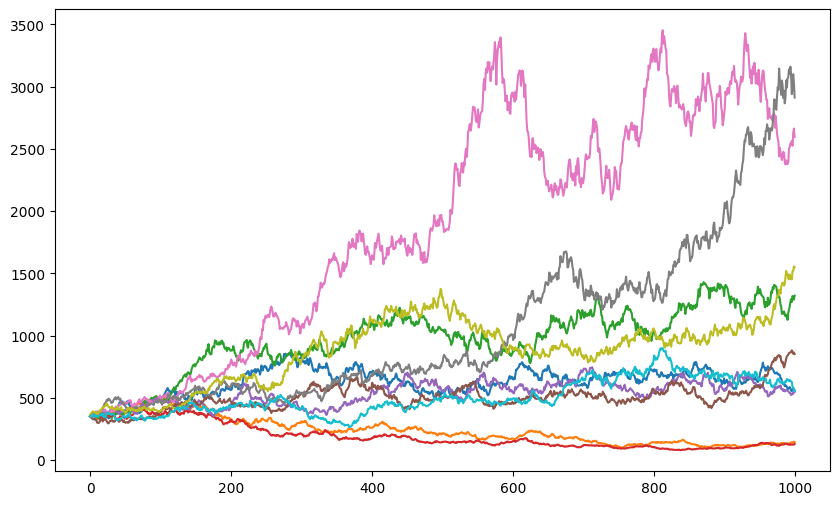

In [40]:
plt.figure(figsize=(10,6))
plt.plot(Future_price);

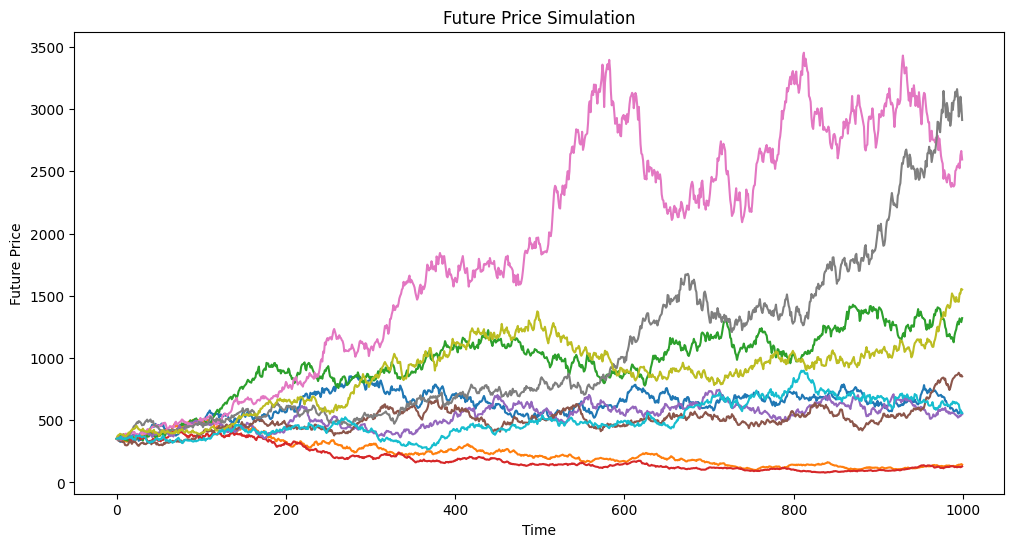

In [43]:
plt.figure(figsize=(12,6))
for i in range(Future_price.shape[1]):
    plt.plot(Future_price[:, i])  # alpha makes overlapping lines visible
plt.xlabel('Time')
plt.ylabel('Future Price')
plt.title('Future Price Simulation')
plt.show()

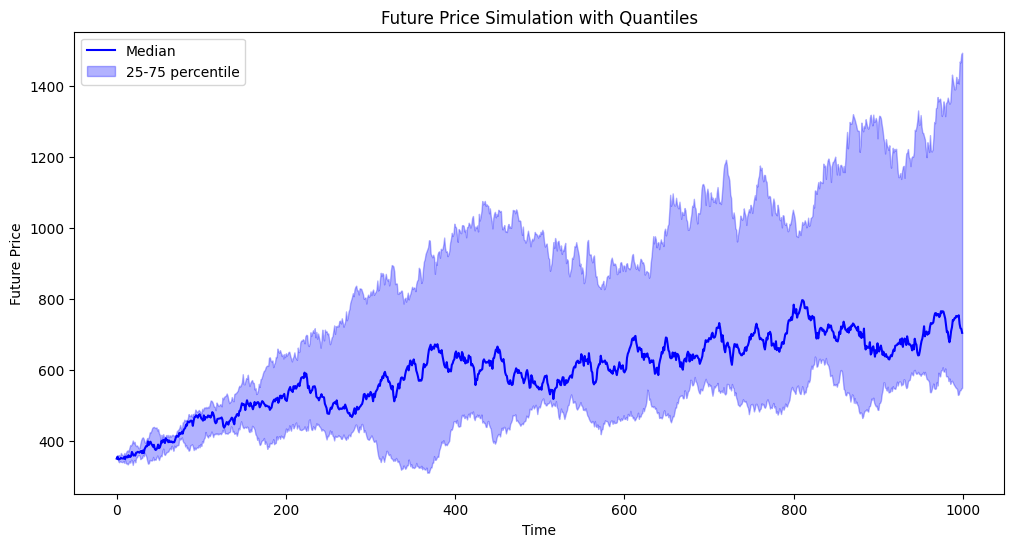

In [42]:
median = np.median(Future_price, axis=1)
q25 = np.percentile(Future_price, 25, axis=1)
q75 = np.percentile(Future_price, 75, axis=1)

plt.figure(figsize=(12,6))
plt.plot(median, label='Median', color='blue')
plt.fill_between(range(Future_price.shape[0]), q25, q75, color='blue', alpha=0.3, label='25-75 percentile')
plt.xlabel('Time')
plt.ylabel('Future Price')
plt.title('Future Price Simulation with Quantiles')
plt.legend()
plt.show()

*In this, we can see 10 different observation paths the stock can move, with a higher potential for upward. I believe and conclude from the Monte Carlo model that AVGO has a higher potential to yield a good return for an investment*